# Upload One HPE COCO-Keypoints Image To Managed Datastore

This notebook uploads exactly one image plus one HPE annotation record in COCO keypoints format to the training API endpoint `POST /managed_datasets`.

It uses pycocotools to load one image and its COCO keypoints annotation.

The payload format matches the backend in `training/app/endpoints/dataset_endpoints.py`: 
- `file`: zip archive containing image file(s)
- `dataset_name`: dataset identifier
- `labels`: JSON list, one label per file
- `metadata`: JSON list, one metadata dict per file

Only COCO keypoints are supported in this notebook.

In [29]:
import io
import json
import os
import zipfile
from datetime import datetime
from pathlib import Path

from pycocotools.coco import COCO
import requests

In [30]:
# --- Configure these values ---
TRAINING_SERVER_URL = os.environ.get("TRAINING_SERVER_URL", "http://localhost:5253")
UPLOAD_URL = f"{TRAINING_SERVER_URL}/managed_datasets"

# Defaults for your local COCO layout under hpe/notebooks/datasets
DATASETS_ROOT = Path(r"C:\Users\mhjde\source\repos\CHIMP\hpe\notebooks\datasets")
COCO_JSON_PATH = DATASETS_ROOT / "annotations_trainval2017" / "person_keypoints_val2017.json"
COCO_IMAGES_ROOT = DATASETS_ROOT / "val2017"

# Optional: set a specific image id from your COCO file. If None, pick a random valid image.
COCO_IMAGE_ID = None

COCO_KEYPOINT_NAMES = [
    "nose", "left_eye", "right_eye", "left_ear", "right_ear",
    "left_shoulder", "right_shoulder", "left_elbow", "right_elbow",
    "left_wrist", "right_wrist", "left_hip", "right_hip",
    "left_knee", "right_knee", "left_ankle", "right_ankle"
]

if not COCO_JSON_PATH.exists():
    raise FileNotFoundError(f"COCO JSON not found: {COCO_JSON_PATH}")

if not COCO_IMAGES_ROOT.exists():
    raise FileNotFoundError(f"COCO images root not found: {COCO_IMAGES_ROOT}")

coco = COCO(str(COCO_JSON_PATH))

person_cat_ids = coco.getCatIds(catNms=["person"])
if not person_cat_ids:
    raise ValueError("Could not find category 'person' in COCO annotations")
person_cat_id = person_cat_ids[0]

if COCO_IMAGE_ID is not None:
    image_ids = [COCO_IMAGE_ID]
else:
    image_ids = coco.getImgIds(catIds=[person_cat_id])

selected_img = None
selected_ann = None
valid_candidates = []

for image_id in image_ids:
    ann_ids = coco.getAnnIds(imgIds=[image_id], catIds=[person_cat_id], iscrowd=False)
    anns = coco.loadAnns(ann_ids)

    # Keep all valid 17-keypoint person annotations for random selection.
    for ann in anns:
        keypoints = ann.get("keypoints", [])
        if len(keypoints) == 51 and ann.get("num_keypoints", 0) > 0:
            img_meta = coco.loadImgs([image_id])[0]
            valid_candidates.append((img_meta, ann))

if not valid_candidates:
    raise ValueError("No val2017 image with a valid person keypoints annotation was found")

if COCO_IMAGE_ID is not None:
    # If a specific image is requested, use its first valid candidate.
    selected_img, selected_ann = valid_candidates[0]
else:
    # Default behavior: choose a random valid candidate each run.
    import random
    selected_img, selected_ann = random.choice(valid_candidates)

IMAGE_PATH = COCO_IMAGES_ROOT / selected_img["file_name"]
if not IMAGE_PATH.exists():
    raise FileNotFoundError(f"Image file not found from COCO metadata: {IMAGE_PATH}")

ARCHIVE_LABEL = "person"
ANNOTATION = {
    "format": "coco_keypoints",
    "image_id": selected_img.get("id"),
    "category_id": person_cat_id,
    "category_name": "person",
    "num_keypoints": selected_ann.get("num_keypoints", 17),
    "keypoint_names": COCO_KEYPOINT_NAMES,
    "keypoints": selected_ann.get("keypoints", []),
    "bbox": selected_ann.get("bbox", []),
    "area": selected_ann.get("area"),
    "iscrowd": selected_ann.get("iscrowd", 0),
    "source": "coco"
}

DATASET_NAME = f"hpe_one_image"

print("Upload URL:", UPLOAD_URL)
print("Dataset:", DATASET_NAME)
print("COCO file:", COCO_JSON_PATH)
print("Images root:", COCO_IMAGES_ROOT)
print("Selected image id:", selected_img.get("id"))
print("Selected annotation id:", selected_ann.get("id"))
print("Total valid candidates:", len(valid_candidates))
print("Image path exists:", IMAGE_PATH.exists())

loading annotations into memory...
Done (t=2.59s)
creating index...
index created!
Upload URL: http://localhost:5253/managed_datasets
Dataset: hpe_one_image
COCO file: C:\Users\mhjde\source\repos\CHIMP\hpe\notebooks\datasets\annotations_trainval2017\person_keypoints_val2017.json
Images root: C:\Users\mhjde\source\repos\CHIMP\hpe\notebooks\datasets\val2017
Selected image id: 31620
Selected annotation id: 445206
Total valid candidates: 6352
Image path exists: True


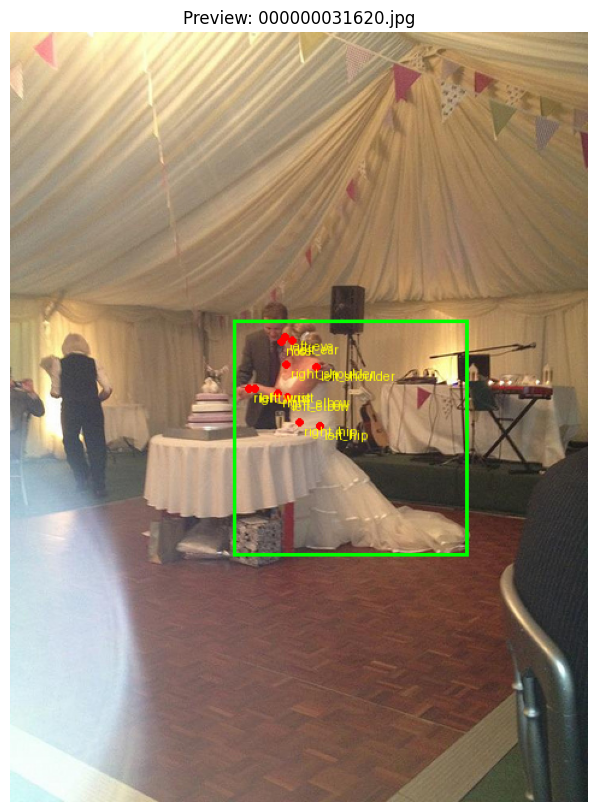

In [31]:
# Preview selected image with annotation overlay before upload
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt

preview_img = Image.open(IMAGE_PATH).convert("RGB")
draw = ImageDraw.Draw(preview_img)

# Draw bounding box [x, y, w, h] if present
bbox = ANNOTATION.get("bbox", [])
if len(bbox) == 4:
    x, y, w, h = bbox
    draw.rectangle([x, y, x + w, y + h], outline="lime", width=3)

# Draw keypoints and labels from COCO triplets [x, y, v]
keypoints = ANNOTATION.get("keypoints", [])
kp_names = ANNOTATION.get("keypoint_names", [])
for i in range(0, len(keypoints), 3):
    kp_idx = i // 3
    xk, yk, vk = keypoints[i], keypoints[i + 1], keypoints[i + 2]
    # COCO visibility: 0 = not labeled, >0 = labeled/visible
    if vk > 0:
        r = 3
        draw.ellipse((xk - r, yk - r, xk + r, yk + r), fill="red")
        if kp_idx < len(kp_names):
            draw.text((xk + 4, yk + 2), kp_names[kp_idx], fill="yellow")

plt.figure(figsize=(10, 10))
plt.imshow(preview_img)
plt.title(f"Preview: {IMAGE_PATH.name}")
plt.axis("off")
plt.show()

In [32]:
if not IMAGE_PATH.exists():
    raise FileNotFoundError(f"Image not found: {IMAGE_PATH}")

if ANNOTATION.get("format") != "coco_keypoints":
    raise ValueError("Only 'coco_keypoints' format is supported in this notebook")

keypoints = ANNOTATION.get("keypoints", [])
if len(keypoints) != 51:
    raise ValueError(f"COCO keypoints must contain 51 values, got {len(keypoints)}")

if len(ANNOTATION.get("keypoint_names", [])) != 17:
    raise ValueError("COCO keypoint_names must contain 17 entries")

if len(ANNOTATION.get("bbox", [])) != 4:
    raise ValueError("COCO bbox must contain 4 values [x, y, w, h]")

# Build an in-memory zip with one file inside a dataset-like folder structure
zip_buffer = io.BytesIO()
archive_name = f"train/{ARCHIVE_LABEL}/{IMAGE_PATH.name}"

with zipfile.ZipFile(zip_buffer, "w", zipfile.ZIP_DEFLATED) as zf:
    zf.writestr(archive_name, IMAGE_PATH.read_bytes())

zip_buffer.seek(0)

# Store full COCO annotation JSON string in y
y_value = json.dumps(ANNOTATION, separators=(",", ":"), sort_keys=True)
labels = [y_value]
metadata = [{
    "exp": "hpe",
    "filename": IMAGE_PATH.name,
    "annotation": ANNOTATION,
    "uploaded_at": datetime.utcnow().isoformat() + "Z"
}]

files = {
    "file": (f"{DATASET_NAME}.zip", zip_buffer.getvalue(), "application/zip"),
    "dataset_name": (None, DATASET_NAME),
    "labels": (None, json.dumps(labels)),
    "metadata": (None, json.dumps(metadata)),
}

response = requests.post(UPLOAD_URL, files=files, timeout=120)

print("Status:", response.status_code)
print("Stored y preview:", y_value[:200] + "..." if len(y_value) > 200 else y_value)
try:
    print("Response JSON:", json.dumps(response.json(), indent=2))
except Exception:
    print("Response text:", response.text)

Status: 400
Stored y preview: {"area":10408.58215,"bbox":[185.79,239.13,194.69,195.94],"category_id":1,"category_name":"person","format":"coco_keypoints","image_id":31620,"iscrowd":0,"keypoint_names":["nose","left_eye","right_eye"...
Response JSON: {
  "error": "Bad Request",
  "message": "Dataset with name 'hpe_one_image' already exists",
  "status-code": 400
}


## Notes
- Install dependency once in the kernel if needed: `pip install pycocotools`.
- If you get connection errors, verify `TRAINING_SERVER_URL` and that services are running.
- If you get a dataset name validation error, keep `DATASET_NAME` alphanumeric/underscore.
- The full COCO annotation JSON is now stored in PostgreSQL `datapoints.y` via the `labels` payload.
- The same annotation is also stored in `metadata.annotation` for convenience.
- This notebook intentionally supports only one HPE annotation schema: COCO keypoints.